In [37]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [19]:
# 2. LOAD DATASET
url = "https://raw.githubusercontent.com/parmveer99solanki99-pixel/Arya-Hackathon-Verse-1.0/refs/heads/main/general_data.csv"
df = pd.read_csv(url)
print("Dataset Loaded Successfully")

print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (4410, 29)


,EmployeeID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,1,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,2,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Female,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,3,32,No,Travel_Frequently,Research & Development,17,4,Other,1,Male,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,4,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,Male,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,5,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Male,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


In [20]:
# 3. Basic Dataset Information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Rows: 4410
Columns: 29

Column Names:
['EmployeeID', 'Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   Age                      4410 non-null   int64  
 2   Attrition                4410 non-null   str    
 3   BusinessTravel           4410 non-null   str    
 4   Depa

In [21]:
# 4. Data Cleaning

print("Missing Values:")
print(df.isnull().sum().sum())

print("Duplicate Rows:", df.duplicated().sum())

Missing Values:
111
Duplicate Rows: 0


In [22]:
drop_columns = [
    "EmployeeID",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df_model = df.drop(columns=drop_columns)

print(df_model.shape)

(4410, 25)


Attrition
No     3699
Yes     711
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


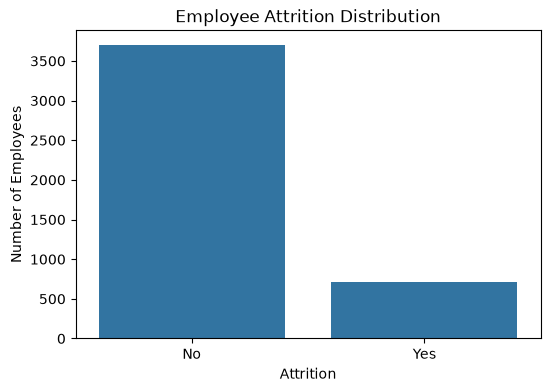

In [23]:
# 5. Target Variable Analysis

print(df["Attrition"].value_counts())

print(df["Attrition"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

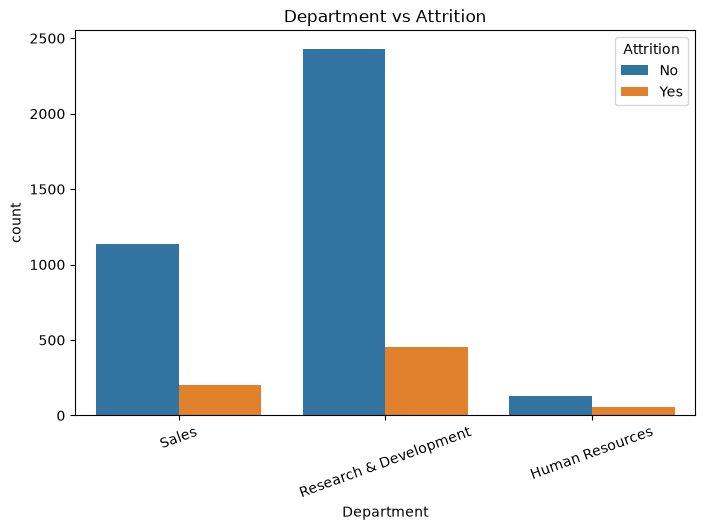

In [24]:
# 6. Department vs Attrition

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Department vs Attrition")
plt.xticks(rotation=20)

plt.show()

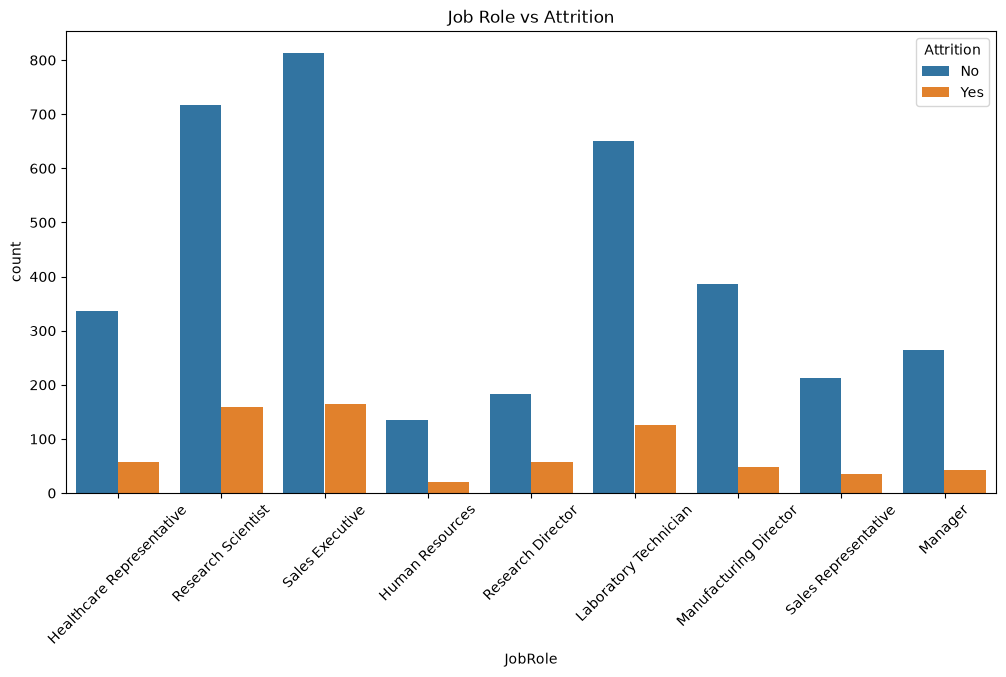

In [25]:
# 7. Job Role vs Attrition

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)

plt.title("Job Role vs Attrition")
plt.xticks(rotation=45)

plt.show()

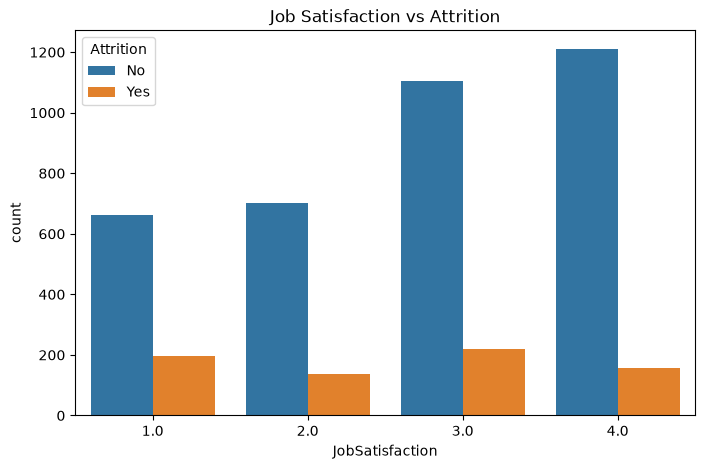

In [26]:
# 8.Job Satisfaction vs Attrition

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

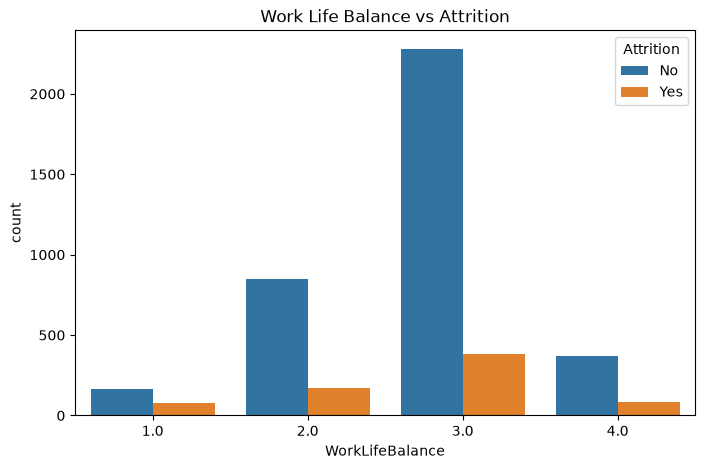

In [27]:
# 9. Work-Life Balance vs Attrition

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work Life Balance vs Attrition")

plt.show()

In [28]:
# 10. Convert Target Variable

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].value_counts())

Attrition
0    3699
1     711
Name: count, dtype: int64


In [29]:
# 11. Separate X and y

X = df_model.drop(columns=["Attrition"])
y = df_model["Attrition"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (4410, 24)
Target: (4410,)


In [30]:
# 12. Identify Categorical and Numerical Columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

Numerical Columns:
['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11564\655964542.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [31]:
# 13. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3528, 24)
Testing Data: (882, 24)


In [32]:
# 15. Logistic Regression

# Separate categorical and numerical columns
categorical_columns = X_train.select_dtypes(
    include=["object", "string"]
).columns

numerical_columns = X_train.select_dtypes(
    exclude=["object", "string"]
).columns


# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)


# Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)


# Train
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")


# Prediction
y_pred_lr = logistic_model.predict(X_test)

print("Prediction completed successfully!")

Logistic Regression trained successfully!
Prediction completed successfully!


In [33]:
# 16. Decision Tree

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=8
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [34]:
# 16. Random Forest

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [40]:
# 17. Compare All Models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_rf, pos_label="Yes", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_rf, pos_label="Yes", zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_rf, pos_label="Yes", zero_division=0)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.848073,0.633333,0.133803,0.220930
1,Decision Tree,0.900227,0.909091,0.422535,0.576923
2,Random Forest,0.995465,1.000000,0.971831,0.985714


In [41]:
# 18. Select Final Model

final_model = random_forest_model

final_predictions = final_model.predict(X_test)

print("Final Model: Random Forest")

print(
    classification_report(
        y_test,
        final_predictions
    )
)

Final Model: Random Forest
              precision    recall  f1-score   support

          No       0.99      1.00      1.00       740
         Yes       1.00      0.97      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



In [42]:
# 19. Save Model

joblib.dump(
    final_model,
    "employee_attrition_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [43]:
# 20. Test Prediction

sample_employee = X_test.iloc[[0]]

prediction = final_model.predict(sample_employee)[0]

if prediction == 1:
    print("Prediction: Employee may leave")
else:
    print("Prediction: Employee likely to stay")

Prediction: Employee likely to stay
